In [238]:
from collections import defaultdict
from pathlib import Path
import os

os.environ["JAX_PLATFORMS"] = "cpu"

import numpy as np
import pandas as pd
import jax
from linear_predictors import make_problem

base = Path(".") / "synthetic_runs"

train_seed = 123
system_seed = 7878
n_predictors = 2
n_boundary_segments = 8
n_samples = 300
boundary_spread = 0.5
function_weight_scale = 1.0
function_bias_scale = 0.3
delegator_hidden_width = 8

folder_template = (
    "ts_{train_seed}_ss_{system_seed}_predictors_{n_predictors}"
    "_segments_{n_boundary_segments}_samples_{n_samples}"
    "_spread_{boundary_spread}_agg_{agg}"
)


def folder_for_agg(agg: str):
    return base / folder_template.format(
        train_seed=train_seed,
        system_seed=system_seed,
        n_predictors=n_predictors,
        n_boundary_segments=n_boundary_segments,
        n_samples=n_samples,
        boundary_spread=boundary_spread,
        agg=agg
    )


def load_problem():
    return make_problem(
        jax.random.key(system_seed),
        n_linear_predictors=n_predictors,
        n_boundary_segments=n_boundary_segments,
        n_samples=n_samples,
        boundary_spread=boundary_spread
    )


def epoch_keys(data):
    n_epochs = len(data["train_loss"])
    return [
        k for k in data.keys()
        if (
            not k.endswith("_predictions")
            and np.asarray(data[k]).ndim == 1
            and len(data[k]) == n_epochs
        )
    ]


system = load_problem()


data = defaultdict(list)

aggs = ("sum", "product")
for agg in aggs:
    folder = folder_for_agg(agg)

    if not folder.exists():
        print(agg, "does not exist")
        continue

    for ent in sorted(folder.iterdir()):
        if not ent.is_file() or not ent.name.endswith(".npz"):
            continue

        stem_parts = ent.stem.split("_")

        if stem_parts[0] != "delegators":
            continue

        delegators = int(stem_parts[1])

        one = np.load(ent)
        one = {k: one[k].squeeze() for k in one.keys()}

        data[agg].append((delegators, one))

data_sorted = dict()

for agg, chain in data.items():
    chain = sorted(chain, key=lambda el: el[0])
    data_sorted[agg] = chain
data = data_sorted
del data_sorted


df = defaultdict(list)
run_i = 0
for agg, chain in data.items():
    for n_delegators, trajectory in chain:

        loss = trajectory["loss"]
        loss = loss
        vl = loss[:, :, system.val_mask]
        tl = loss[:, :, ~system.val_mask]
        tl = tl.mean(axis=-1)
        vl = vl.mean(axis=-1)

        n = tl.shape[0]
        df["agg"].extend([agg] * n)
        df["delegators"].extend([n_delegators] * n)
        df["run_i"].extend([run_i] * n)
        df["epoch"].extend(np.arange(n))
        df["train_loss"].extend(tl.mean(axis=-1).tolist())
        df["val_loss"].extend(vl.mean(axis=-1).tolist())

        df["train_loss_q025"].extend(np.quantile(tl, 0.025, axis=-1).tolist())
        df["train_loss_q975"].extend(np.quantile(tl, 0.975, axis=-1).tolist())

        df["val_loss_q025"].extend(np.quantile(vl, 0.025, axis=-1).tolist())
        df["val_loss_q975"].extend(np.quantile(vl, 0.975, axis=-1).tolist())

        run_i += 1

df_epoch = pd.DataFrame(df)


assert df_epoch.groupby("run_i")["epoch"].max().unique().size
df_last_epoch = df_epoch[df_epoch["epoch"] == df_epoch["epoch"].max()]

_idx = df_epoch.groupby("run_i")["val_loss"].idxmin()
df = df_epoch.loc[_idx].reset_index(drop=True)

display(df.sample(min(8, len(df))))

,agg,delegators,run_i,epoch,train_loss,val_loss,train_loss_q025,train_loss_q975,val_loss_q025,val_loss_q975
7,product,1,7,381,0.049887,0.037575,0.043705,0.063988,0.029412,0.061910
9,product,4,9,233,0.046081,0.051860,0.018377,0.083554,0.015294,0.087494
11,product,16,11,91,0.039026,0.039005,0.018091,0.087802,0.017682,0.081624
3,sum,8,3,737,0.053242,0.048935,0.030694,0.126597,0.026593,0.143956
8,product,2,8,203,0.055624,0.052041,0.012842,0.133759,0.018778,0.149270
0,sum,1,0,382,0.049886,0.037576,0.043709,0.063992,0.029406,0.061899
12,product,32,12,219,0.039346,0.038990,0.007478,0.089346,0.008689,0.084257
10,product,8,10,315,0.043423,0.045248,0.017824,0.084085,0.018874,0.081974


Text(0, 0.5, 'Validatin loss (Early stopping)')

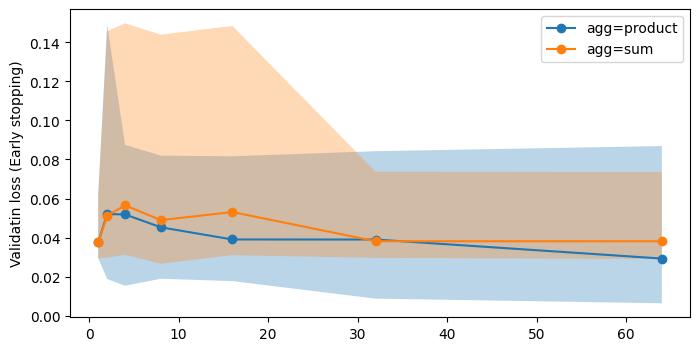

In [239]:
from matplotlib import pyplot as plt


fig, ax = plt.subplots(figsize=(8, 4))

for agg, df_g in df.groupby("agg"):
    
    df_g = df_g.sort_values("delegators")
    ax.plot(df_g["delegators"], df_g["val_loss"], marker="o", label=f"agg={agg}")
    ax.fill_between(df_g["delegators"], df_g["val_loss_q975"], df_g["val_loss_q025"], alpha=0.3)

ax.legend()
# ax.set_yscale("log")
ax.set_ylabel("Validatin loss (Early stopping)")


Text(0, 0.5, 'Train loss')

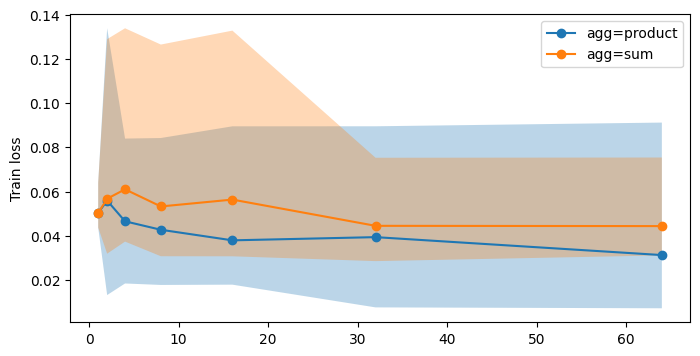

In [240]:
from matplotlib import pyplot as plt


fig, ax = plt.subplots(figsize=(8, 4))

for agg, df_g in df_last_epoch.groupby("agg"):
    
    df_g = df_g.sort_values("delegators")
    ax.plot(df_g["delegators"], df_g["train_loss"], marker="o", label=f"agg={agg}")
    ax.fill_between(df_g["delegators"], df_g["train_loss_q975"], df_g["train_loss_q025"], alpha=0.3)

ax.legend()
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_ylabel("Train loss")

(750, 10, 300)


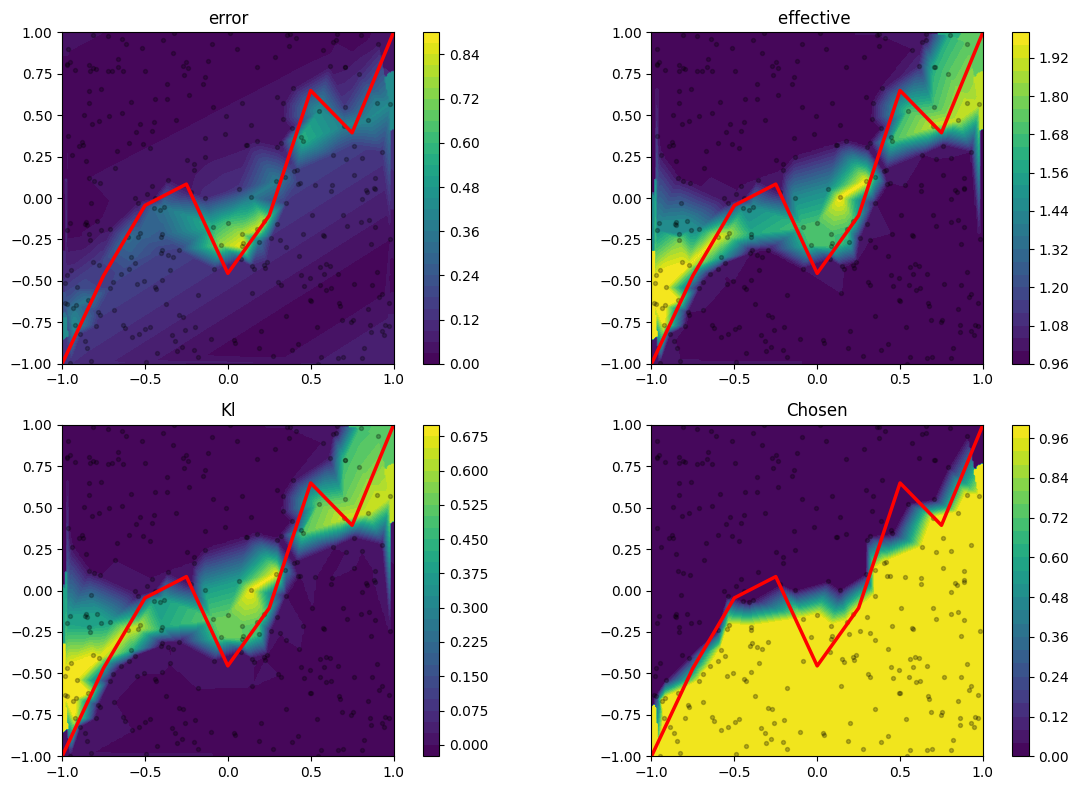

(<Figure size 1200x800 with 8 Axes>,
 array([<Axes: title={'center': 'error'}>,
        <Axes: title={'center': 'effective '}>,
        <Axes: title={'center': 'Kl'}>, <Axes: title={'center': 'Chosen'}>],
       dtype=object),
 np.int64(516))

In [237]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def pick(data, agg, delegators):
    return next(t for d, t in data[agg] if d == delegators)

def epoch_id(t, system, seed_i=0, epoch="best"):
    if epoch == "last":
        return t["loss"].shape[0] - 1
    if epoch == "best":
        return t["loss"][:, seed_i, system.val_mask].mean(-1).argmin()
    return epoch

def interp(x, z, pts, method="linear"):
    a = griddata(x, z, pts, method=method)
    b = griddata(x, z, pts, method="nearest")
    return np.where(np.isnan(a), b, a)

def plot_error(
    data,
    system,
    agg="sum",
    delegators=3,
    seed_i=0,
    epoch="best",
    grid_n=250,
):
    t = pick(data, agg, delegators)
    e = epoch_id(t, system, seed_i, epoch)

    x = system.x
    print(t["predictions.aggregated_y"].shape)
    yhat = t["predictions.aggregated_y"][e, seed_i]
    w = t["predictions.aggregated_d"][e, seed_i]
    delegations = t["predictions.delegations"][e, seed_i]

    kl = np.mean(np.sum(delegations * np.log((delegations + 1e-6) / (w[:, np.newaxis, :] + 1e-6)), axis=-1), axis=-1)

    # kl = np.sum()

    err = abs(yhat - system.y)
    eff = np.exp(-(w * np.log(w + 1e-6)).sum(-1))
    chos = w.argmax(-1).astype(np.float32)


    u = np.linspace(-1, 1, grid_n)
    X0, X1 = np.meshgrid(u, u)
    pts = np.c_[X0.ravel(), X1.ravel()]

    Zerr = interp(x, err, pts).reshape(X0.shape)
    Zeff = interp(x, eff, pts).reshape(X0.shape)
    Zkl = interp(x, kl, pts).reshape(X0.shape)
    Zcos = interp(x, chos, pts).reshape(X0.shape)


    fig, ax = plt.subplots(2, 2, figsize=(12, 8))
    ax = ax.ravel()

    c = ax[0].contourf(X0, X1, Zerr, levels=30)
    ax[0].plot(system.boundary_x, system.boundary_y, "r", lw=2.5)
    ax[0].scatter(x[:, 0], x[:, 1], s=8, c="k", alpha=0.25)
    ax[0].set_title(f"error")
    ax[0].set_aspect("equal")
    fig.colorbar(c, ax=ax[0])

    c = ax[1].contourf(X0, X1, Zeff, levels=30)
    ax[1].plot(system.boundary_x, system.boundary_y, "r", lw=2.5)
    ax[1].scatter(x[:, 0], x[:, 1], s=8, c="k", alpha=0.25)
    ax[1].set_title(f"effective ")
    ax[1].set_aspect("equal")
    fig.colorbar(c, ax=ax[1])

    c = ax[2].contourf(X0, X1, Zkl, levels=30)
    ax[2].plot(system.boundary_x, system.boundary_y, "r", lw=2.5)
    ax[2].scatter(x[:, 0], x[:, 1], s=8, c="k", alpha=0.25)
    ax[2].set_title(f"Kl")
    ax[2].set_aspect("equal")
    fig.colorbar(c, ax=ax[2])


    c = ax[3].contourf(X0, X1, Zcos, levels=30)
    ax[3].plot(system.boundary_x, system.boundary_y, "r", lw=2.5)
    ax[3].scatter(x[:, 0], x[:, 1], s=8, c="k", alpha=0.25)
    ax[3].set_title(f"Chosen")
    ax[3].set_aspect("equal")
    fig.colorbar(c, ax=ax[3])
    fig.tight_layout()

    plt.show()
    return fig, ax, e

plot_error(data, system, agg="sum", delegators=32, seed_i=1, epoch="best")

In [227]:
import plotly.graph_objects as go

def plot_predictor_planes(
    data,
    system,
    agg="sum",
    delegators=3,
    seed_i=0,
    epoch="best",
    grid_n=80,
    show_data=True,
):
    t = pick(data, agg, delegators)
    e = epoch_id(t, system, seed_i, epoch)

    x = system.x
    preds = t["predictions.predictions"][e, seed_i]

    u = np.linspace(-1, 1, grid_n)
    X0, X1 = np.meshgrid(u, u)
    pts = np.c_[X0.ravel(), X1.ravel()]

    fig = go.Figure()

    for i in range(preds.shape[-1]):
        Z = interp(x, preds[:, i], pts).reshape(X0.shape)
        fig.add_trace(go.Surface(
            x=X0,
            y=X1,
            z=Z,
            opacity=0.65,
            showscale=False,
            name=f"predictor {i}",
        ))

    if show_data:
        fig.add_trace(go.Scatter3d(
            x=x[:, 0],
            y=x[:, 1],
            z=system.y,
            mode="markers",
            marker=dict(size=3),
            name="data",
        ))

    fig.update_layout(
        title=f"individual predictor outputs | {agg=} {delegators=} {seed_i=} epoch={e}",
        scene=dict(
            xaxis_title="x0",
            yaxis_title="x1",
            zaxis_title="y",
        ),
        width=1200,
        height=700,
    )

    fig.show()
    return fig, e


plot_predictor_planes(data, system, agg="sum", delegators=8, seed_i=1, epoch="best")

(Figure({
     'data': [{'name': 'predictor 0',
               'opacity': 0.65,
               'showscale': False,
               'type': 'surface',
               'x': {'bdata': ('AAAAAAAA8L9hfleLmzDvv8L8rhY3Ye' ... '4WN2HuP2B+V4ubMO8/AAAAAAAA8D8='),
                     'dtype': 'f8',
                     'shape': '80, 80'},
               'y': {'bdata': ('AAAAAAAA8L8AAAAAAADwvwAAAAAAAP' ... 'AAAADwPwAAAAAAAPA/AAAAAAAA8D8='),
                     'dtype': 'f8',
                     'shape': '80, 80'},
               'z': {'bdata': ('AAAAILet6D8AAAAgt63oPwAAACC3re' ... 'BgUaDovwAAAGBRoOi/AAAAYFGg6L8='),
                     'dtype': 'f8',
                     'shape': '80, 80'}},
              {'name': 'predictor 1',
               'opacity': 0.65,
               'showscale': False,
               'type': 'surface',
               'x': {'bdata': ('AAAAAAAA8L9hfleLmzDvv8L8rhY3Ye' ... '4WN2HuP2B+V4ubMO8/AAAAAAAA8D8='),
                     'dtype': 'f8',
                     'shape': '8

Text(0, 0.5, 'Training loss')

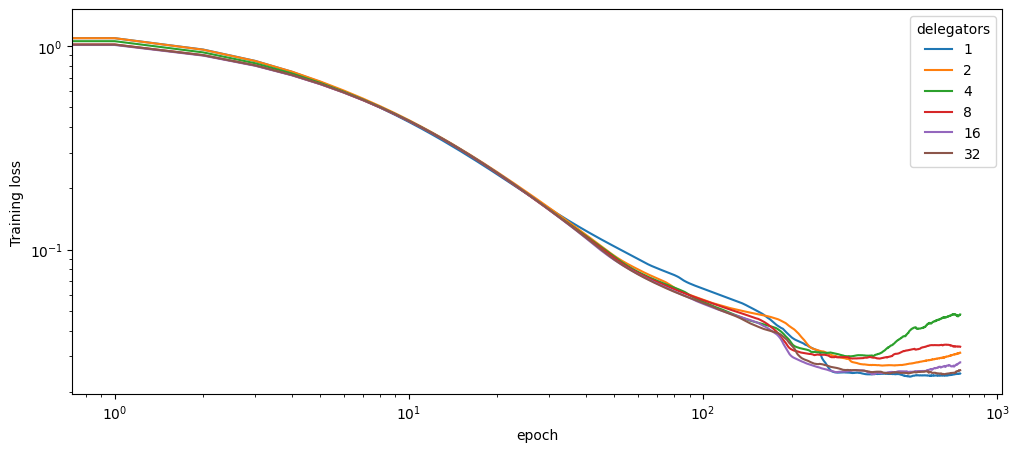

In [118]:
fig, ax = plt.subplots(figsize=(12, 5))

ax = (
    df_epoch
    .pivot(index="epoch", columns="delegators", values="val_loss")
    .plot.line(ax=ax)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Training loss")


Text(0, 0.5, 'Valid loss')

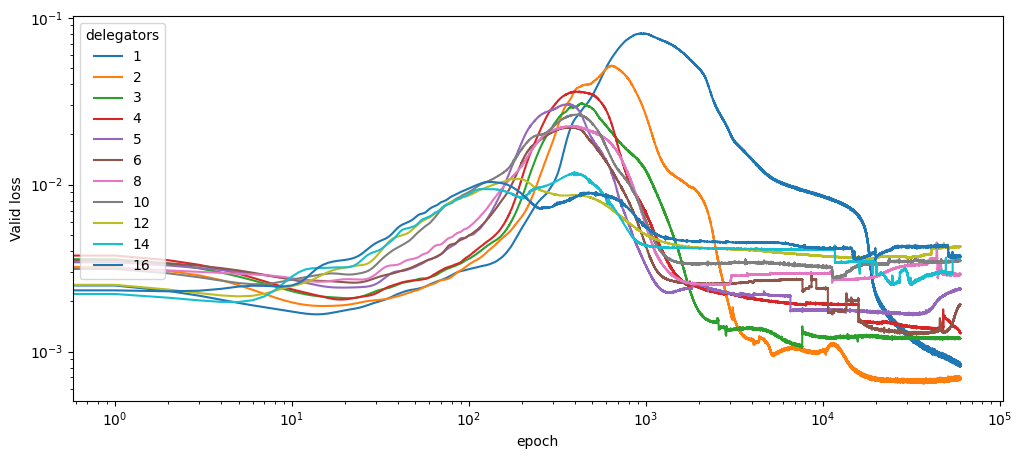

In [109]:
fig, ax = plt.subplots(figsize=(12, 5))

ax = (
    df_epoch.loc[~df_epoch["frozen"]]
    .pivot(index="epoch", columns="delegators", values="val_loss")
    .plot.line(ax=ax)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel("Valid loss")
